In [1]:
# Importing the Libraries, which are the basic requirement for our MODEL_BUILDING_PROCESS
import numpy as np
import pandas as pd
import tensorflow as tf

from PIL import Image
import os

import matplotlib.pyplot as plt
%matplotlib inline

### Download Dataset from Kaggle

To download the dataset from Kaggle, you need to:

1. Go to your Kaggle account (https://www.kaggle.com/me).
2. Click on 'Account' in the navigation bar.
3. Scroll down to the 'API' section and click 'Create New API Token'. This will download a `kaggle.json` file.
4. Upload this `kaggle.json` file to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar, and then clicking the 'Upload' button.

In [13]:
# Install Kaggle API client
!pip install kaggle

In [14]:
# Create .kaggle directory and move kaggle.json there
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [15]:
# Download the dataset
# The dataset link is: https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign
# The command is: kaggle datasets download -d <owner>/<dataset-name>
!kaggle datasets download -d meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

# Unzip the downloaded dataset
!unzip gtsrb-german-traffic-sign.zip -d gtsrb-german-traffic-sign

Streaming output truncated to the last 5000 lines.
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00010.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00011.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00012.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00013.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00014.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00015.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00016.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00017.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00018.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00019.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00020.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00021.png  
  inflating: gtsrb-german-traffic-sign/train/5/00005_00053_00022.png  
  inflating: gtsrb-german-

Now that the data is downloaded and unzipped, I will modify the data loading cell to use the correct path.

## Dataset Link: https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign

In [2]:
os.getcwd()

'/content'

In [3]:
os.listdir()

['.config', 'sample_data']

In [5]:
current_working_directory = os.getcwd()

In [6]:
current_working_directory

'/content'

In [7]:
current_working_directory_items = os.listdir()

In [8]:
current_working_directory_items

['.config', 'sample_data']

In [9]:
number_of_classes = 43

In [10]:
Data = []

Labels = []

In [16]:
#Preprocessing step: Here we are using RGB data.
# It has 3 channels.

for i in range(number_of_classes):
    # Corrected path for Colab environment
    path = os.path.join('/content/gtsrb-german-traffic-sign/Train', str(i))
    images = os.listdir(path)
    for j in images:
        try:
            # Corrected path for Colab environment, using os.path.join for robustness
            image = Image.open(os.path.join(path, j))
            image = image.resize((32,32))
            image = np.array(image)
            image = image / 255.0
            Data.append(image)
            Labels.append(i)
        except Exception as e:
            print(e)

In [18]:
type(Data) , type(Labels)

(list, list)

In [19]:
Data[0]

array([[[0.49411765, 0.53333333, 0.56470588],
        [0.50588235, 0.50980392, 0.54509804],
        [0.5372549 , 0.50196078, 0.5372549 ],
        ...,
        [0.38431373, 0.30196078, 0.21568627],
        [0.54509804, 0.50588235, 0.46666667],
        [0.54901961, 0.52941176, 0.52941176]],

       [[0.4745098 , 0.50588235, 0.50980392],
        [0.49019608, 0.50196078, 0.50980392],
        [0.50588235, 0.50196078, 0.50980392],
        ...,
        [0.5372549 , 0.49019608, 0.44705882],
        [0.53333333, 0.51372549, 0.49411765],
        [0.5254902 , 0.51372549, 0.50588235]],

       [[0.45882353, 0.47843137, 0.49019608],
        [0.47058824, 0.49019608, 0.49803922],
        [0.4745098 , 0.49803922, 0.50588235],
        ...,
        [0.51764706, 0.50588235, 0.47058824],
        [0.50588235, 0.50196078, 0.48235294],
        [0.50196078, 0.50196078, 0.49411765]],

       ...,

       [[0.42745098, 0.45098039, 0.44313725],
        [0.43529412, 0.44705882, 0.42745098],
        [0.44313725, 0

In [20]:
# Conversion of list into Numpy arrays

Data = np.array(Data)

Labels = np.array(Labels)

In [21]:
os.mkdir("Preprocessed_Data_&_Labels_&_SAVED_MODEL")

In [22]:
os.getcwd()

'/content'

In [23]:
os.chdir("Preprocessed_Data_&_Labels_&_SAVED_MODEL")

In [24]:
os.getcwd()

'/content/Preprocessed_Data_&_Labels_&_SAVED_MODEL'

In [25]:
# Saving Data & Labels, so that in futuere we won't required to perform preprocessing again.

np.save("Data" , Data)

np.save("Labels" , Labels)

In [26]:
os.getcwd()

'/content/Preprocessed_Data_&_Labels_&_SAVED_MODEL'

In [27]:
os.chdir(current_working_directory)

In [28]:
os.getcwd()

'/content'

In [29]:
os.listdir()

['.config',
 'Preprocessed_Data_&_Labels_&_SAVED_MODEL',
 'gtsrb-german-traffic-sign.zip',
 'gtsrb-german-traffic-sign',
 'sample_data']

In [ ]:
#Since we have stored our preprocessed Data & Label earlier,
# Now we are LOADING them.

In [30]:
os.getcwd()

'/content'

In [31]:
os.chdir("Preprocessed_Data_&_Labels_&_SAVED_MODEL")

In [32]:
os.getcwd()

'/content/Preprocessed_Data_&_Labels_&_SAVED_MODEL'

In [33]:
os.listdir()

['Data.npy', 'Labels.npy']

In [34]:
#Assigning them in repective variables...

Data = np.load('Data.npy')

Labels = np.load('Labels.npy')

In [35]:
Data[0]

array([[[0.49411765, 0.53333333, 0.56470588],
        [0.50588235, 0.50980392, 0.54509804],
        [0.5372549 , 0.50196078, 0.5372549 ],
        ...,
        [0.38431373, 0.30196078, 0.21568627],
        [0.54509804, 0.50588235, 0.46666667],
        [0.54901961, 0.52941176, 0.52941176]],

       [[0.4745098 , 0.50588235, 0.50980392],
        [0.49019608, 0.50196078, 0.50980392],
        [0.50588235, 0.50196078, 0.50980392],
        ...,
        [0.5372549 , 0.49019608, 0.44705882],
        [0.53333333, 0.51372549, 0.49411765],
        [0.5254902 , 0.51372549, 0.50588235]],

       [[0.45882353, 0.47843137, 0.49019608],
        [0.47058824, 0.49019608, 0.49803922],
        [0.4745098 , 0.49803922, 0.50588235],
        ...,
        [0.51764706, 0.50588235, 0.47058824],
        [0.50588235, 0.50196078, 0.48235294],
        [0.50196078, 0.50196078, 0.49411765]],

       ...,

       [[0.42745098, 0.45098039, 0.44313725],
        [0.43529412, 0.44705882, 0.42745098],
        [0.44313725, 0

In [36]:
Labels[0]

np.int64(0)

In [37]:
os.getcwd()

'/content/Preprocessed_Data_&_Labels_&_SAVED_MODEL'

In [38]:
os.chdir("..")

In [39]:
os.getcwd()

'/content'

In [40]:
os.listdir()

['.config',
 'Preprocessed_Data_&_Labels_&_SAVED_MODEL',
 'gtsrb-german-traffic-sign.zip',
 'gtsrb-german-traffic-sign',
 'sample_data']

In [41]:
Data[1]

array([[[0.6745098 , 0.59607843, 0.55294118],
        [0.65882353, 0.4627451 , 0.35686275],
        [0.68235294, 0.45490196, 0.33333333],
        ...,
        [0.70196078, 0.45098039, 0.33333333],
        [0.6745098 , 0.46666667, 0.34117647],
        [0.65098039, 0.4745098 , 0.35686275]],

       [[0.67058824, 0.61176471, 0.58431373],
        [0.62352941, 0.4745098 , 0.37254902],
        [0.63921569, 0.4745098 , 0.35686275],
        ...,
        [0.77647059, 0.59607843, 0.50980392],
        [0.73333333, 0.61960784, 0.53333333],
        [0.68627451, 0.63137255, 0.55294118]],

       [[0.65882353, 0.64705882, 0.62745098],
        [0.65490196, 0.63921569, 0.62352941],
        [0.67058824, 0.64705882, 0.63529412],
        ...,
        [0.63921569, 0.61960784, 0.57647059],
        [0.63921569, 0.62352941, 0.59215686],
        [0.64313725, 0.63921569, 0.61568627]],

       ...,

       [[0.49803922, 0.49411765, 0.53333333],
        [0.52941176, 0.52941176, 0.60784314],
        [0.45882353, 0

In [42]:
Labels[1]

np.int64(0)

In [43]:
Labels

array([ 0,  0,  0, ..., 42, 42, 42])

In [44]:
print(f"Shape of Data : {Data.shape}\nShape of Labels :{Labels.shape}")

Shape of Data : (39209, 32, 32, 3)
Shape of Labels :(39209,)


In [45]:
# Splitting the dataset into training & testing : 70% & 30 % respectively.

from sklearn.model_selection import train_test_split

X_train , X_test , Y_train , Y_test = train_test_split(Data , Labels , test_size = 0.30 , random_state = 0)

In [46]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {Y_test.shape}")

X_train shape: (27446, 32, 32, 3)
X_test shape: (11763, 32, 32, 3)
Y_train shape: (27446,)
X_test shape: (11763,)


In [47]:
# Now we are converting the labels to onehot encoding.

from keras.utils import to_categorical

Y_train = to_categorical(Y_train, 43)
Y_test = to_categorical(Y_test, 43)

In [48]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"X_test shape: {Y_test.shape}")

X_train shape: (27446, 32, 32, 3)
X_test shape: (11763, 32, 32, 3)
Y_train shape: (27446, 43)
X_test shape: (11763, 43)


In [49]:
X_train.shape[1:4]

(32, 32, 3)

In [53]:
from keras.models import Sequential, load_model

from keras.layers import Conv2D, MaxPool2D, Dense

from keras.layers import Flatten, Dropout

In [65]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=X_train.shape[1:]))
model.add(MaxPool2D(pool_size=(2, 2)))


model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))


model.add(Flatten())

model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.25))

model.add(Dense(128, activation='relu'))
model.add(Dropout(rate=0.20))


model.add(Dense(43, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [66]:
#Compilation of the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

tb_callback = tf.keras.callbacks.TensorBoard(log_dir="logs", histogram_freq=1)

In [67]:
#Fitting of the model
history__of__model = model.fit(X_train, Y_train, batch_size=32, epochs=40, validation_split=0.3, callbacks= [tb_callback])

Epoch 1/40
601/601 ━━━━━━━━━━━━━━━━━━━━ 36s 56ms/step - accuracy: 0.4078 - loss: 2.0898 - val_accuracy: 0.8107 - val_loss: 0.6112
Epoch 2/40
601/601 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.8644 - loss: 0.4286 - val_accuracy: 0.9515 - val_loss: 0.1797
Epoch 3/40
601/601 ━━━━━━━━━━━━━━━━━━━━ 31s 52ms/step - accuracy: 0.9382 - loss: 0.2018 - val_accuracy: 0.9732 - val_loss: 0.0962
Epoch 4/40
601/601 ━━━━━━━━━━━━━━━━━━━━ 33s 55ms/step - accuracy: 0.9619 - loss: 0.1293 - val_accuracy: 0.9769 - val_loss: 0.0839
Epoch 5/40
601/601 ━━━━━━━━━━━━━━━━━━━━ 32s 52ms/step - accuracy: 0.9705 - loss: 0.0988 - val_accuracy: 0.9756 - val_loss: 0.0841
Epoch 6/40
601/601 ━━━━━━━━━━━━━━━━━━━━ 33s 54ms/step - accuracy: 0.9744 - loss: 0.0810 - val_accuracy: 0.9761 - val_loss: 0.0776
Epoch 7/40
601/601 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9800 - loss: 0.0613 - val_accuracy: 0.9830 - val_loss: 0.0541
Epoch 8/40
601/601 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.9833 - loss: 0.0522 - 

KeyboardInterrupt: 

In [57]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,275 (1.85 MB)

 Trainable params: 162,091 (633.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 324,184 (1.24 MB)

In [58]:
model.evaluate(X_test , Y_test)

368/368 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9884 - loss: 0.0607


[0.06070622801780701, 0.9883533120155334]

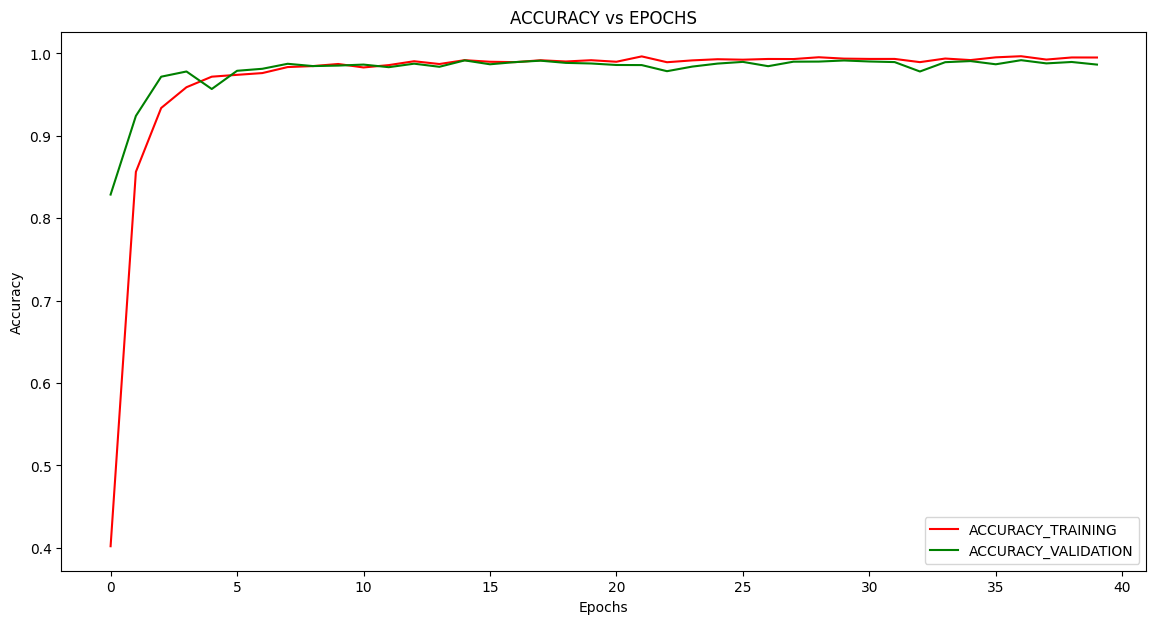

In [59]:
"PLOTTING ACCURACY GRAPH"
                # length , Height
plt.figure(figsize=(14,7))
plt.plot(history__of__model.history['accuracy'],'r-' ,label='ACCURACY_TRAINING' )
plt.plot(history__of__model.history['val_accuracy'] , 'g-', label='ACCURACY_VALIDATION')
plt.title('ACCURACY vs EPOCHS')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

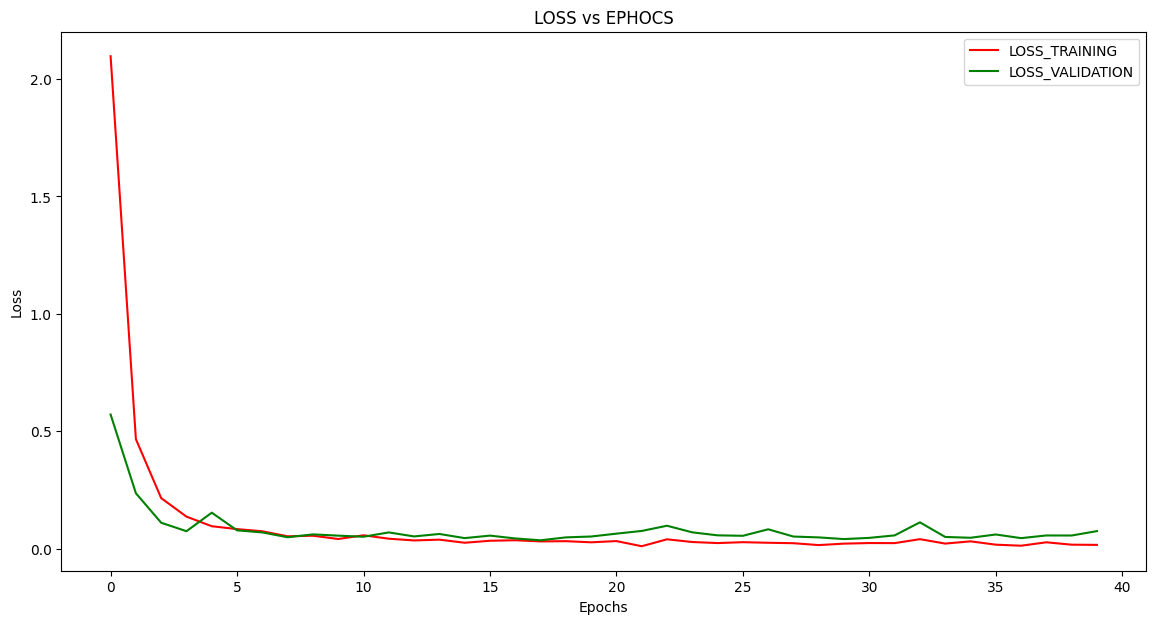

In [60]:
# Plotting Loss Graph
                # length , Height
plt.figure(figsize=(14,7))
plt.plot(history__of__model.history['loss'], 'r-' , label='LOSS_TRAINING')
plt.plot(history__of__model.history['val_loss'], 'g-' ,label='LOSS_VALIDATION')
plt.title('LOSS vs EPHOCS')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [61]:
yyyy___pred = np.argmax(model.predict(X_test), axis=-1)

368/368 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step


In [62]:
yyyy___pred

array([12, 13, 31, ...,  4,  7, 38])

In [69]:
# TESTING THE MODEL THAT WE HAV BUILT ON THE TEST DATA.

def model_testing(testcsv):
    y_test = pd.read_csv(testcsv)
    label = y_test['ClassId'].values
    imgs = y_test['Path'].values
    data=[]
    base_image_path = os.path.dirname(testcsv) # This will be '/content/gtsrb-german-traffic-sign'
    for img_relative_path in imgs:
        try:
            # Construct the absolute path by joining the base path with the relative image path
            img_full_path = os.path.join(base_image_path, img_relative_path)
            image = Image.open(img_full_path)
            image = image.resize((32,32))
            data.append(np.array(image))
        except Exception as e:
            print(f"Error loading image {img_relative_path}: {e}")
            # Optionally, you might want to skip or handle corrupted images
            # For now, we'll just print the error and continue.
            continue
    X_test=np.array(data)
    X_test = X_test / 255.0
    return X_test,label

In [70]:
X_test, label = model_testing('/content/gtsrb-german-traffic-sign/Test.csv')

In [71]:
Y_pred = np.argmax(model.predict(X_test) , axis = -1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step


In [72]:
Y_pred

array([16,  1, 38, ..., 32,  7, 10])

In [73]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report

acc = accuracy_score(label, Y_pred)*100
cm = confusion_matrix(label, Y_pred)
cr = classification_report(label, Y_pred)

In [74]:
print(f"Accuracy : {acc}%")
print(f"Confusion Matrix :\n{cm}")
print(f"Classification Report :\n{cr}")

Accuracy : 95.10688836104512%
Confusion Matrix :
[[ 60   0   0 ...   0   0   0]
 [  4 705   1 ...   0   0   0]
 [  0  14 731 ...   0   0   0]
 ...
 [  0   0   0 ...  88   0   0]
 [  0   0   0 ...   0  52   0]
 [  0   0   0 ...   0   6  83]]
Classification Report :
              precision    recall  f1-score   support

           0       0.87      1.00      0.93        60
           1       0.96      0.98      0.97       720
           2       0.94      0.97      0.96       750
           3       0.95      0.98      0.96       450
           4       0.97      0.97      0.97       660
           5       0.98      0.87      0.92       630
           6       0.99      0.76      0.86       150
           7       0.94      0.98      0.96       450
           8       0.97      0.93      0.95       450
           9       0.95      1.00      0.98       480
          10       1.00      0.98      0.99       660
          11       0.90      0.94      0.92       420
          12       1.00      0.9

In [75]:
import seaborn as sb

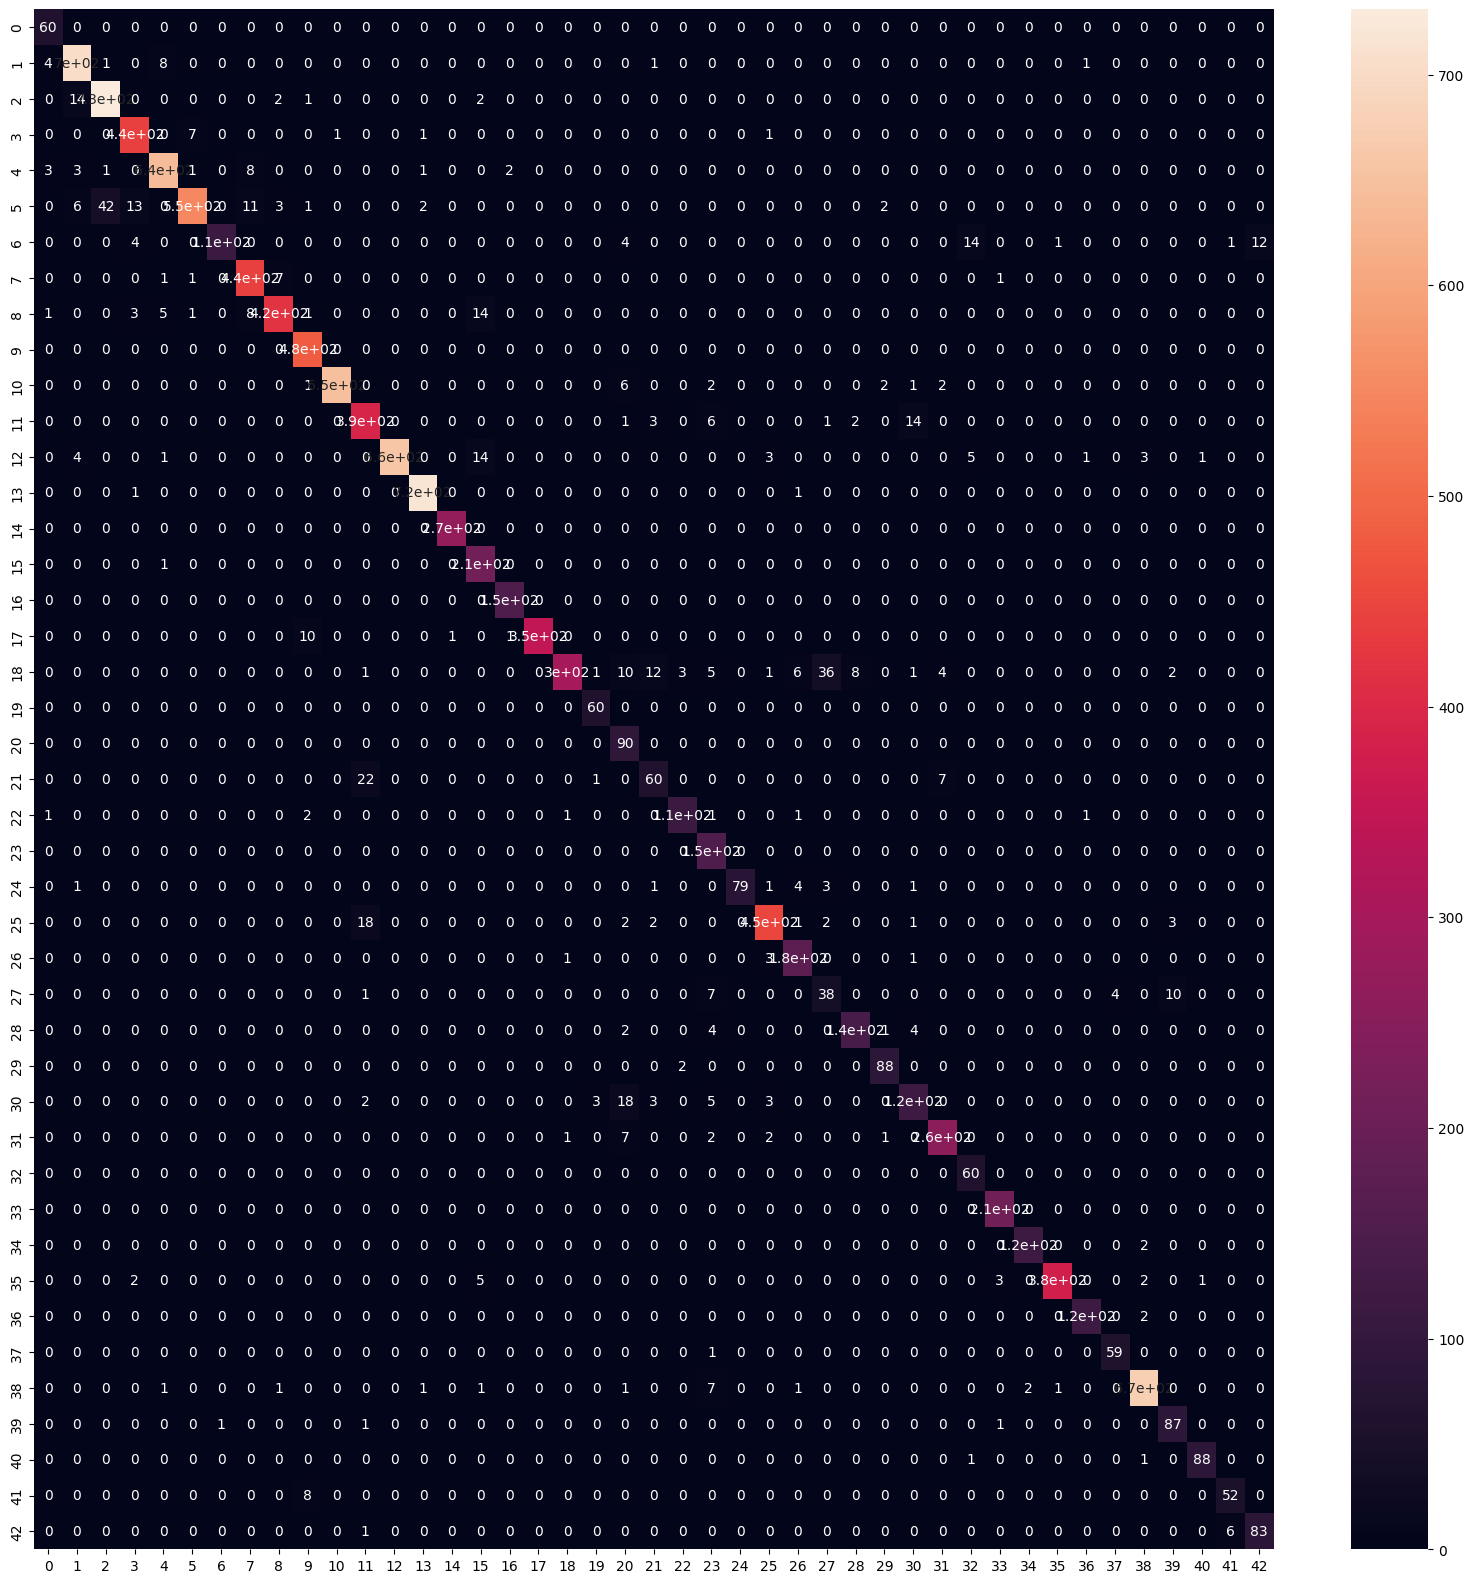

In [76]:
plt.figure(figsize=(20,20))
sb.heatmap(cm , annot=True)
plt.show()

In [77]:
os.listdir()

['.config',
 'Preprocessed_Data_&_Labels_&_SAVED_MODEL',
 'logs',
 'gtsrb-german-traffic-sign.zip',
 'gtsrb-german-traffic-sign',
 'sample_data']

In [78]:
os.chdir("Preprocessed_Data_&_Labels_&_SAVED_MODEL")

In [79]:
# Now for future use we are saving our BUILT_MODEL.

model.save("R_G_B_model.h5")

In [ ]:
# LOADING THE MODEL

In [80]:
model = load_model("R_G_B_model.h5")

In [81]:
classes = { 0:'Speed limit (20km/h)',
            1:'Speed limit (30km/h)',
            2:'Speed limit (50km/h)',
            3:'Speed limit (60km/h)',
            4:'Speed limit (70km/h)',
            5:'Speed limit (80km/h)',
            6:'End of speed limit (80km/h)',
            7:'Speed limit (100km/h)',
            8:'Speed limit (120km/h)',
            9:'No passing',
            10:'No passing veh over 3.5 tons',
            11:'Right-of-way at intersection',
            12:'Priority road',
            13:'Yield',
            14:'Stop',
            15:'No vehicles',
            16:'Veh > 3.5 tons prohibited',
            17:'No entry',
            18:'General caution',
            19:'Dangerous curve left',
            20:'Dangerous curve right',
            21:'Double curve',
            22:'Bumpy road',
            23:'Slippery road',
            24:'Road narrows on the right',
            25:'Road work',
            26:'Traffic signals',
            27:'Pedestrians',
            28:'Children crossing',
            29:'Bicycles crossing',
            30:'Beware of ice/snow',
            31:'Wild animals crossing',
            32:'End speed + passing limits',
            33:'Turn right ahead',
            34:'Turn left ahead',
            35:'Ahead only',
            36:'Go straight or right',
            37:'Go straight or left',
            38:'Keep right',
            39:'Keep left',
            40:'Roundabout mandatory',
            41:'End of no passing',
            42:'End no passing veh > 3.5 tons' }

In [82]:
os.chdir("..")

In [83]:
os.getcwd()

'/content'

In [84]:
os.listdir()

['.config',
 'Preprocessed_Data_&_Labels_&_SAVED_MODEL',
 'logs',
 'gtsrb-german-traffic-sign.zip',
 'gtsrb-german-traffic-sign',
 'sample_data']

In [ ]:
# from PIL import Image
# import numpy as np
# import matplotlib.pyplot as plt
# %matplotlib inline

In [85]:
def testing_image(img):
    data=[]
    image = Image.open(img)
    image = image.resize((32,32))
    data.append(np.array(image))
    X_test=np.array(data)
    X_test = X_test / 255.0
    Y_pred = np.argmax(model.predict(X_test) , axis=-1)
    return image,Y_pred

In [86]:
os.getcwd()

'/content'

In [87]:
os.listdir()

['.config',
 'Preprocessed_Data_&_Labels_&_SAVED_MODEL',
 'logs',
 'gtsrb-german-traffic-sign.zip',
 'gtsrb-german-traffic-sign',
 'sample_data']

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Predicted traffic sign is:  Bumpy road


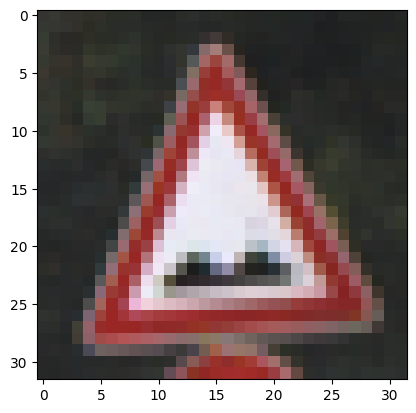

In [88]:
plot,prediction = testing_image('/content/gtsrb-german-traffic-sign/Test/00500.png')
s = [str(i) for i in prediction]
a = int("".join(s))
print("Predicted traffic sign is: ", classes[a])
plt.imshow(plot)
plt.show()

### Test with an Uploaded Image

Now you can upload your own image to test the model. An upload button will appear below. Select your image, and the model will predict the traffic sign.

In [91]:
from google.colab import files

uploaded = files.upload()

# Get the filename of the first uploaded file
for fn in uploaded.keys():
    uploaded_file_path = fn
    print(f"User uploaded file: {uploaded_file_path}")
    break # Assuming only one file will be uploaded at a time

Saving 00006.png to 00006.png
User uploaded file: 00006.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted traffic sign is:  General caution


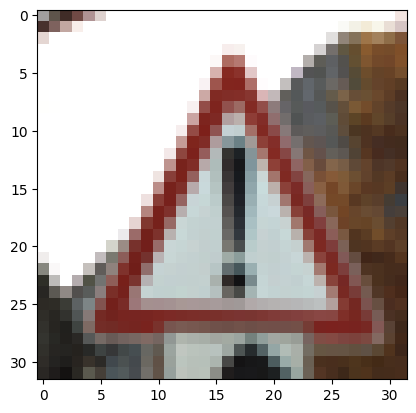

In [92]:
plot, prediction = testing_image(uploaded_file_path)
s = [str(i) for i in prediction]
a = int("".join(s))
print("Predicted traffic sign is: ", classes[a])
plt.imshow(plot)
plt.show()